In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from scipy import stats

In [ ]:
# https://www.kaggle.com/datasets/maharshipandya/-spotify-tracks-dataset
df = pd.read_csv('dataset.csv')
df.head(5)

,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,...,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,...,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,...,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,...,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,...,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


In [60]:
df.dtypes

Unnamed: 0            int64
track_id                str
artists                 str
album_name              str
track_name              str
popularity            int64
duration_ms           int64
explicit               bool
danceability        float64
energy              float64
key                   int64
loudness            float64
mode                  int64
speechiness         float64
acousticness        float64
instrumentalness    float64
liveness            float64
valence             float64
tempo               float64
time_signature        int64
track_genre             str
dtype: object

In [61]:
df.describe()

,Unnamed: 0,popularity,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
count,114000.000000,114000.000000,1.140000e+05,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000
mean,56999.500000,33.238535,2.280292e+05,0.566800,0.641383,5.309140,-8.258960,0.637553,0.084652,0.314910,0.156050,0.213553,0.474068,122.147837,3.904035
std,32909.109681,22.305078,1.072977e+05,0.173542,0.251529,3.559987,5.029337,0.480709,0.105732,0.332523,0.309555,0.190378,0.259261,29.978197,0.432621
min,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,-49.531000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,28499.750000,17.000000,1.740660e+05,0.456000,0.472000,2.000000,-10.013000,0.000000,0.035900,0.016900,0.000000,0.098000,0.260000,99.218750,4.000000
50%,56999.500000,35.000000,2.129060e+05,0.580000,0.685000,5.000000,-7.004000,1.000000,0.048900,0.169000,0.000042,0.132000,0.464000,122.017000,4.000000
75%,85499.250000,50.000000,2.615060e+05,0.695000,0.854000,8.000000,-5.003000,1.000000,0.084500,0.598000,0.049000,0.273000,0.683000,140.071000,4.000000
max,113999.000000,100.000000,5.237295e+06,0.985000,1.000000,11.000000,4.532000,1.000000,0.965000,0.996000,1.000000,1.000000,0.995000,243.372000,5.000000


In [62]:
df.nunique()

Unnamed: 0          114000
track_id             89741
artists              31437
album_name           46589
track_name           73608
popularity             101
duration_ms          50697
explicit                 2
danceability          1174
energy                2083
key                     12
loudness             19480
mode                     2
speechiness           1489
acousticness          5061
instrumentalness      5346
liveness              1722
valence               1790
tempo                45653
time_signature           5
track_genre            114
dtype: int64

In [63]:
df['popularity_tier'] = pd.cut(df['popularity'],
    bins=[-1, 25, 50, 75, 100],
    labels=['Low', 'Mid', 'Hit', 'Super Hit'])

df['tempo_category'] = pd.cut(df['tempo'],
    bins=[0, 100, 140, 250],
    labels=['Slow', 'Medium', 'Fast'])

df['valence_category'] = pd.cut(df['valence'],
    bins=[-1, 0.33, 0.66, 1.0],
    labels=['Sad/Dark', 'Neutral', 'Happy/Cheerful'])

Distribution of tracks by properties


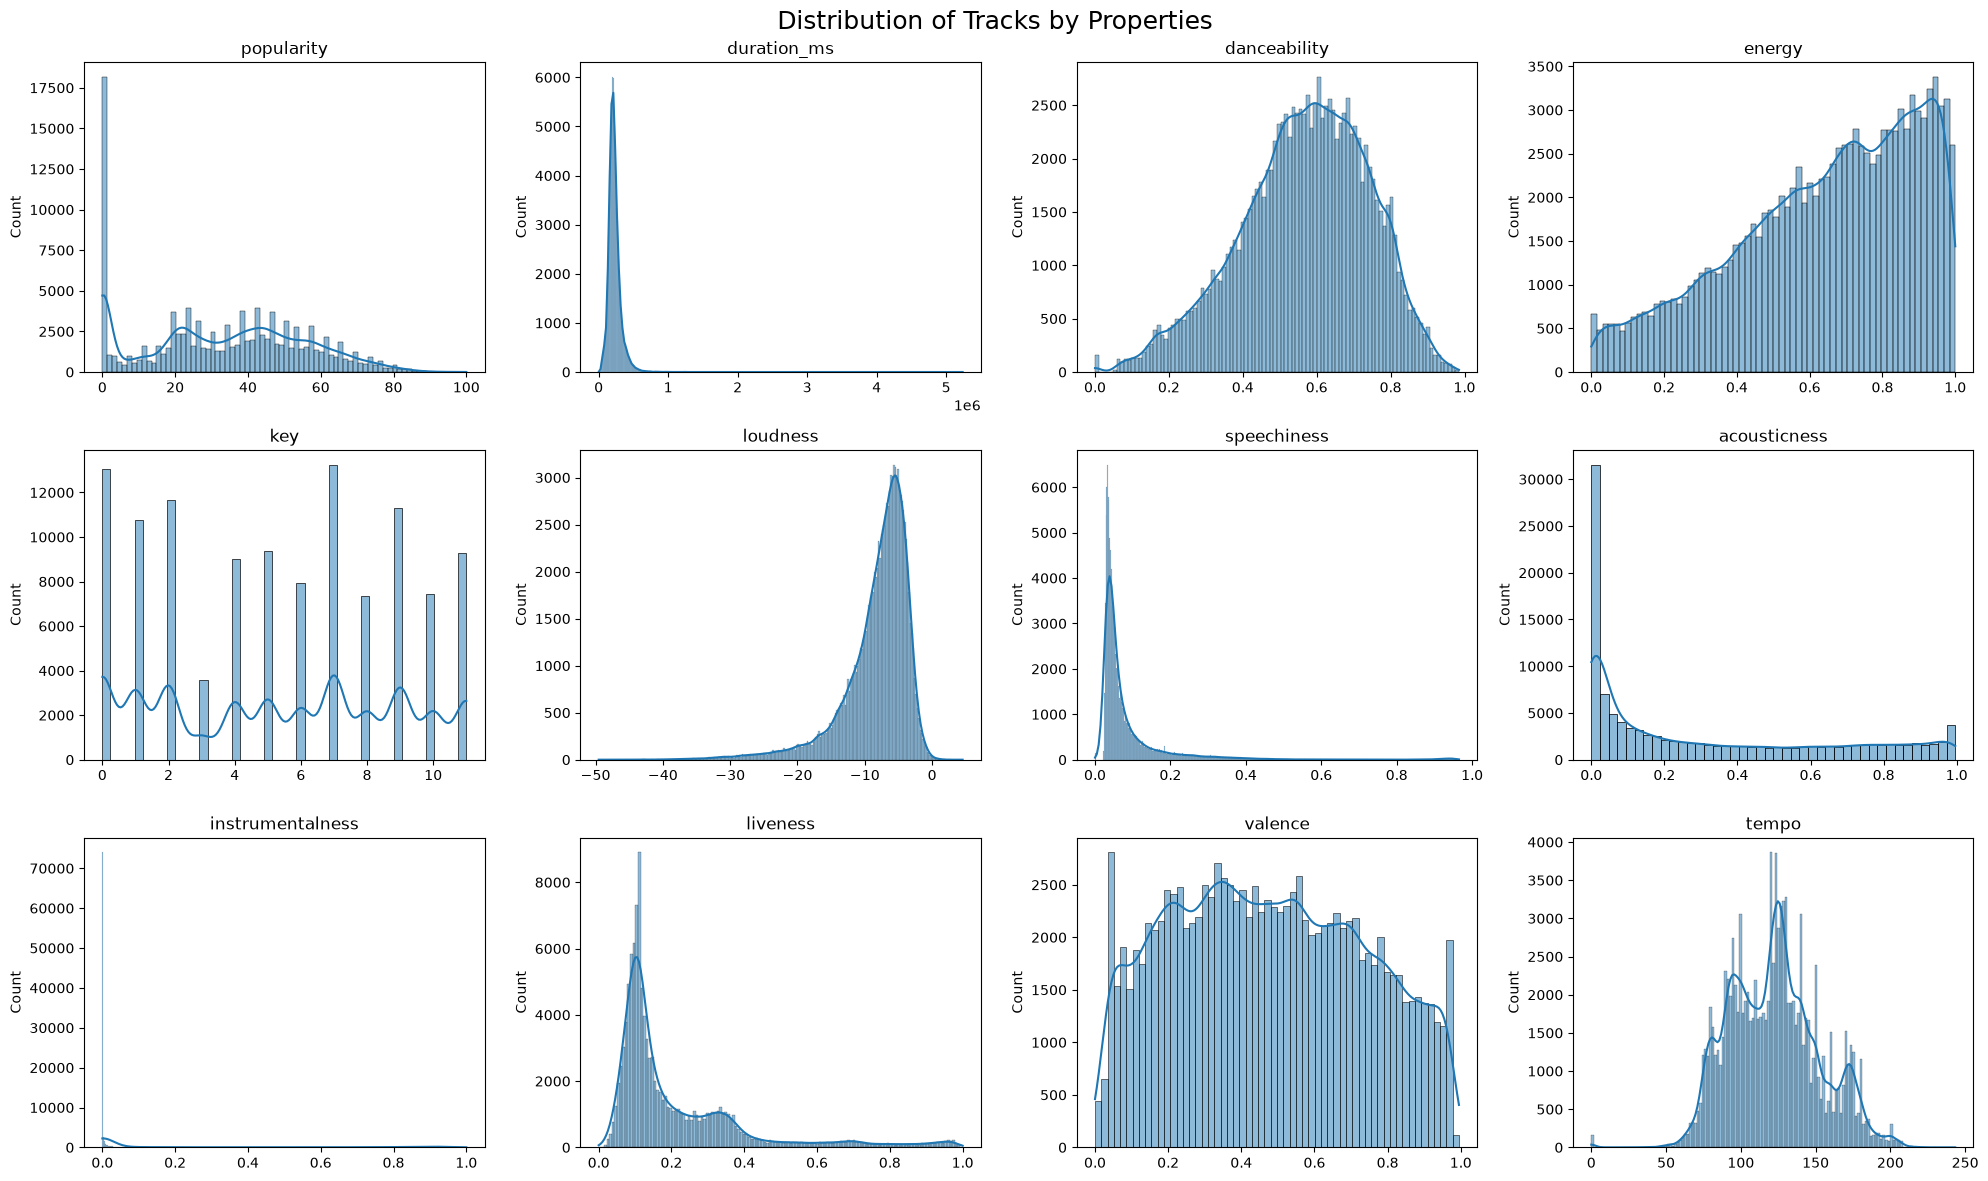

In [64]:
print("Distribution of tracks by properties")

keys = [
    "popularity",
    "duration_ms",
    "danceability",
    "energy",
    "key",
    "loudness",
    "speechiness",
    "acousticness",
    "instrumentalness",
    "liveness",
    "valence",
    "tempo",
    "danceability_factor"
]

# Create a 3 x 4 grid
fig, axes = plt.subplots(3, 4, figsize=(20, 12))
axes = axes.flatten()

for ax, key in zip(axes, keys):
    sns.histplot(data=df, x=key, ax=ax, kde=True)
    ax.set_title(key)
    ax.set_xlabel("")
    ax.set_ylabel("Count")

plt.suptitle("Distribution of Tracks by Properties", fontsize=18)
plt.tight_layout()
plt.show()


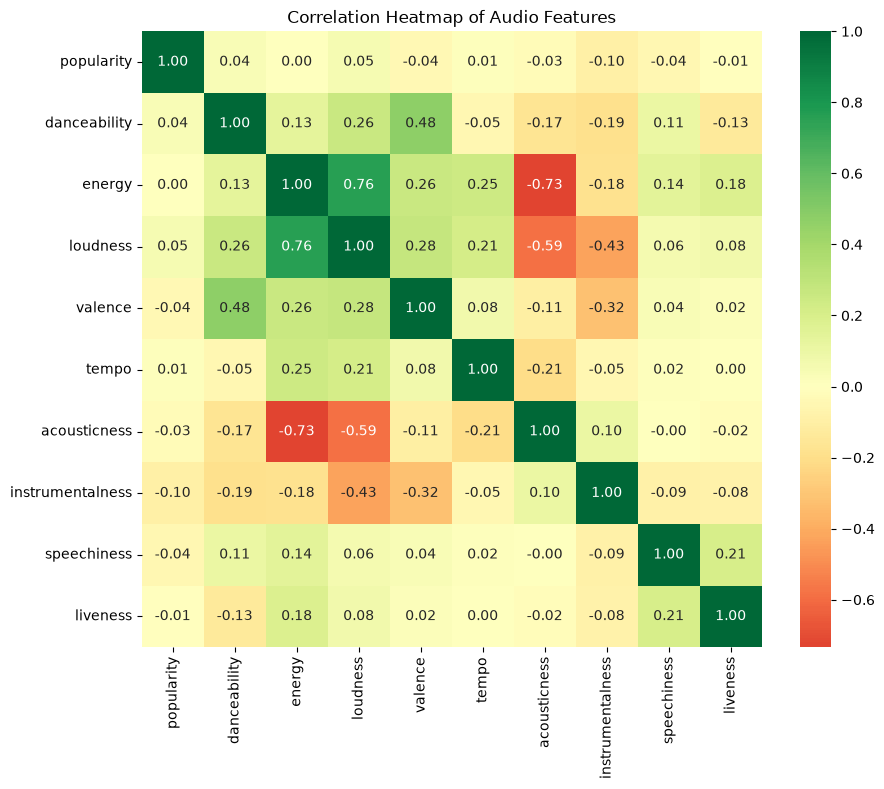

In [65]:
corr_vars = ["popularity", "danceability", "energy", "loudness", "valence", "tempo",
             "acousticness", "instrumentalness", "speechiness", "liveness"]
corr_vars = [c for c in corr_vars if c in df.columns]
corr = df[corr_vars].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdYlGn", center=0)
plt.title("Correlation Heatmap of Audio Features")
plt.show()

In [66]:
explicit_pop = df.loc[df["explicit"] == True, "popularity"]
clean_pop = df.loc[df["explicit"] == False, "popularity"]

t_stat, p_value = stats.ttest_ind(explicit_pop, clean_pop, equal_var=False)

print(f"Non-explicit: n={len(clean_pop):,}, mean={clean_pop.mean():.2f}, std={clean_pop.std():.2f}")
print(f"Explicit:     n={len(explicit_pop):,}, mean={explicit_pop.mean():.2f}, std={explicit_pop.std():.2f}")
print(f"\nT-statistic: {t_stat:.2f}")
print(f"P-value: {p_value:.4f}")

Non-explicit: n=104,253, mean=32.94, std=22.08
Explicit:     n=9,747, mean=36.45, std=24.32

T-statistic: 13.76
P-value: 0.0000


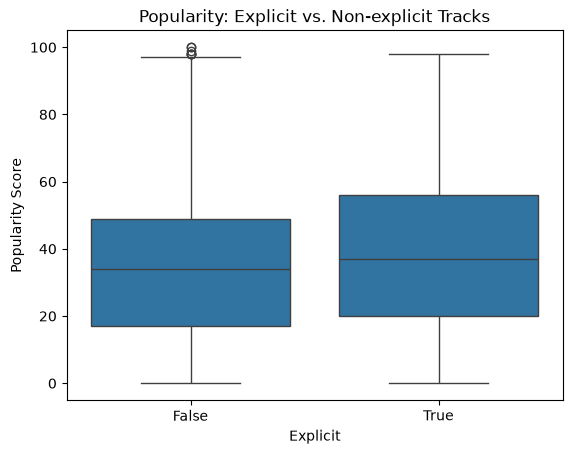

In [67]:
plt.figure()
sns.boxplot(x="explicit", y="popularity", data=df)
plt.title("Popularity: Explicit vs. Non-explicit Tracks")
plt.xlabel("Explicit")
plt.ylabel("Popularity Score")
plt.show()

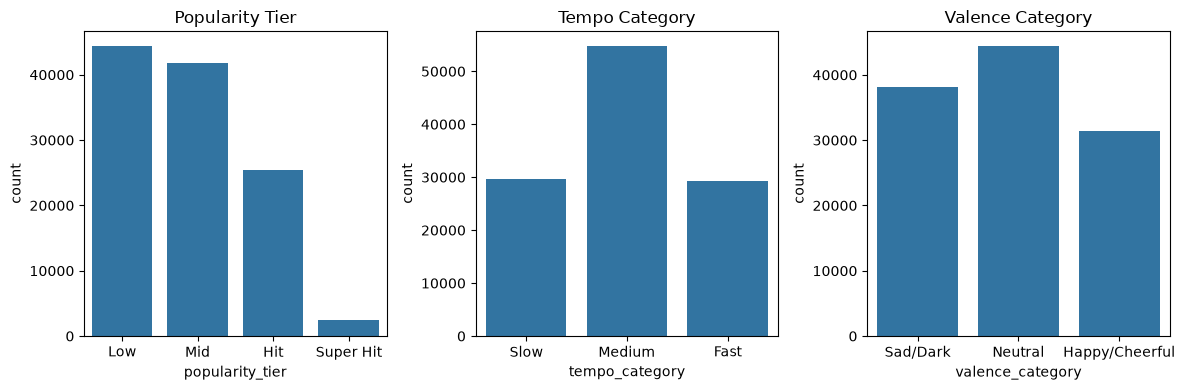

In [75]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

sns.countplot(data=df, x="popularity_tier", ax=axes[0])
axes[0].set_title("Popularity Tier")

sns.countplot(data=df, x="tempo_category", ax=axes[1])
axes[1].set_title("Tempo Category")

sns.countplot(data=df, x="valence_category", ax=axes[2])
axes[2].set_title("Valence Category")

plt.tight_layout()
plt.show()


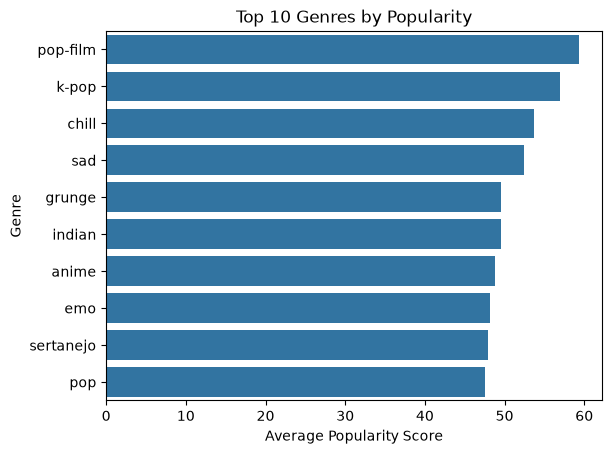

In [69]:
top_genres = df.groupby("track_genre")["popularity"].mean().sort_values(ascending=False).head(10)

plt.figure()
sns.barplot(x=top_genres.values, y=top_genres.index)
plt.title("Top 10 Genres by Popularity")
plt.xlabel("Average Popularity Score")
plt.ylabel("Genre")
plt.show()

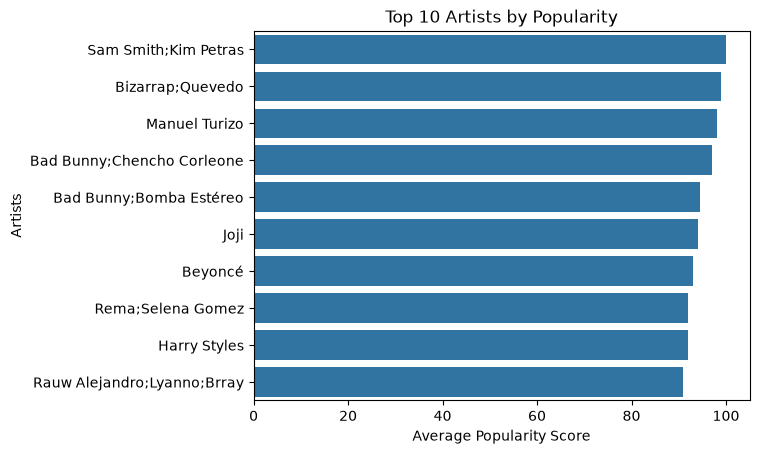

In [70]:
top_artist = df.groupby("artists")["popularity"].mean().sort_values(ascending=False).head(10)

plt.figure()
sns.barplot(x=top_artist.values, y=top_artist.index)
plt.title("Top 10 Artists by Popularity")
plt.xlabel("Average Popularity Score")
plt.ylabel("Artists")
plt.show()

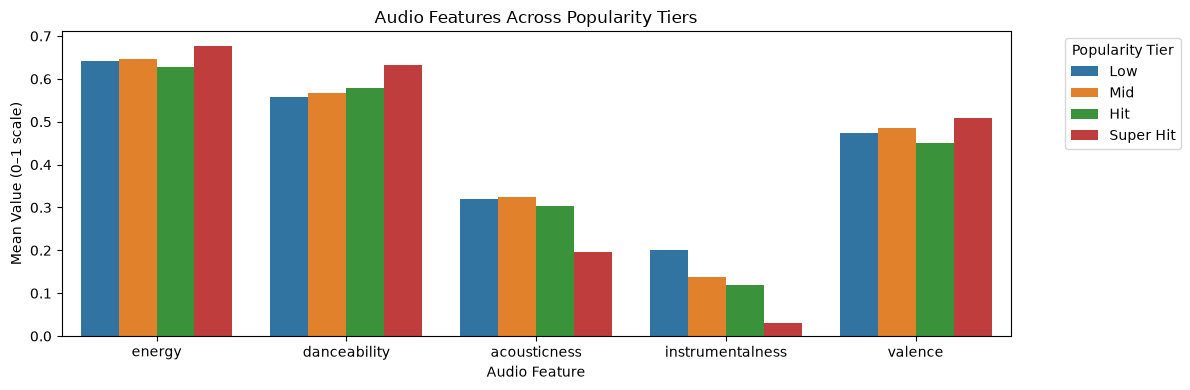

In [78]:
audio_features_by_popularity = (df.groupby('popularity_tier', observed=False)
                                [['energy', 'danceability', 'acousticness', 'instrumentalness', 'valence']]
                                .mean())

melted_df = audio_features_by_popularity.reset_index().melt(id_vars='popularity_tier')
plt.figure(figsize=(12, 4))
sns.barplot(data=melted_df, x='variable', y='value', hue='popularity_tier')
plt.xlabel('Audio Feature')
plt.ylabel('Mean Value (0–1 scale)')
plt.title('Audio Features Across Popularity Tiers')
plt.legend(title='Popularity Tier', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()